# Actividad 3 — Proyecto 1: Identificación del Problema

> **Reto:** Identificar un problema real que pueda ser resuelto mediante aprendizaje automático y definir su estructura de desarrollo.

## Contenidos
1. [Contexto y caso de uso](#1-contexto-y-caso-de-uso)
2. [Definición del problema de ML](#2-definición-del-problema-de-ml)
3. [Obtención y exploración de datos](#3-obtención-y-exploración-de-datos)
4. [Análisis exploratorio (EDA)](#4-análisis-exploratorio-eda)
5. [Ruta de ejecución del proyecto](#5-ruta-de-ejecución-del-proyecto)
6. [Modelos candidatos y métricas](#6-modelos-candidatos-y-métricas)
7. [Viabilidad y consideraciones](#7-viabilidad-y-consideraciones)


## 1. Contexto y caso de uso

### El problema real

Las **enfermedades cardiovasculares (ECV)** son la principal causa de muerte a nivel mundial. Según la OMS, representan aproximadamente **17.9 millones de muertes al año** (31% de todas las muertes globales).

El diagnóstico temprano es crítico: la identificación de pacientes en riesgo permite intervenciones preventivas que reducen la mortalidad significativamente. Sin embargo, el diagnóstico tradicional depende de múltiples pruebas (electrocardiograma, angiografía, prueba de esfuerzo) que son **costosas, invasivas y no siempre accesibles** en todos los contextos clínicos.

### La oportunidad con ML

Un modelo de machine learning entrenado con datos clínicos y demográficos puede:
- **Priorizar pacientes** para pruebas diagnósticas más costosas.
- **Asistir al médico** como segunda opinión basada en evidencia.
- **Operar en contextos de bajos recursos** donde no hay acceso a angiografía.

### Dataset seleccionado

El **Heart Disease Dataset (Cleveland)** del repositorio UCI ML es uno de los datasets médicos más estudiados en la literatura de ML. Contiene 303 registros con 14 atributos clínicos y demográficos recolectados por el Cleveland Clinic Foundation.

**Criterios de selección:**
- Dataset **real y público** (UCI Machine Learning Repository).
- **Balanceado** y con **baja tasa de valores faltantes**.
- **Benchmark establecido**: cientos de publicaciones académicas lo referencian.
- **Multivariado**: combina variables continuas, discretas y categóricas.
- **Tamaño manejable**: 303 instancias permiten iteración rápida dentro del cronograma del curso.


## 2. Definición del problema de ML

### Formulación

| Elemento | Descripción |
|----------|-------------|
| **Tipo de problema** | Clasificación binaria supervisada |
| **Objetivo (target)** | Presencia de enfermedad cardíaca (`num` > 0) |
| **Features** | 13 atributos: edad, sexo, tipo de dolor torácico, presión arterial, colesterol, glucemia, ECG, frecuencia cardíaca máxima, angina por ejercicio, depresión ST, pendiente ST, vasos principales, talasemia |
| **Clases** | 0 = sin enfermedad (160 casos) / 1 = con enfermedad (137 casos) |
| **Métrica principal** | **Recall (sensibilidad)** — es más grave un falso negativo (paciente enfermo no detectado) que un falso positivo |
| **Métricas complementarias** | F1-Score, ROC-AUC, Accuracy, Precision |

### Pregunta de investigación

> *"¿Se puede predecir la presencia de enfermedad cardíaca a partir de datos clínicos no invasivos con una sensibilidad superior al 80%?"*


## 3. Obtención y exploración de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='viridis')
alt.renderers.enable('default')
np.random.seed(42)

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


### Descarga desde UCI ML Repository

In [2]:
# Descarga directa desde UCI ML Repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]

df_raw = pd.read_csv(url, names=column_names, na_values='?')

print(f'Datos descargados: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas')
print(f'\nPrimeras 5 filas:')
print(df_raw.head().to_string(index=False))


Datos descargados: 303 filas x 14 columnas

Primeras 5 filas:
 age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  num
63.0  1.0 1.0     145.0 233.0  1.0      2.0    150.0    0.0      2.3    3.0 0.0   6.0    0
67.0  1.0 4.0     160.0 286.0  0.0      2.0    108.0    1.0      1.5    2.0 3.0   3.0    2
67.0  1.0 4.0     120.0 229.0  0.0      2.0    129.0    1.0      2.6    2.0 2.0   7.0    1
37.0  1.0 3.0     130.0 250.0  0.0      0.0    187.0    0.0      3.5    3.0 0.0   3.0    0
41.0  0.0 2.0     130.0 204.0  0.0      2.0    172.0    0.0      1.4    1.0 0.0   3.0    0


### Limpieza inicial

In [3]:
# Identificación de valores faltantes
print('Valores faltantes por columna:')
missing = df_raw.isnull().sum()
print(missing[missing > 0] if (missing > 0).any() else 'Ningún valor faltante detectado en el parseo inicial.')

# Eliminamos filas con valores faltantes (son pocas, 6 de 303)
df_clean = df_raw.dropna().copy()
print(f'\nRegistros después de limpieza: {df_clean.shape[0]} de {df_raw.shape[0]}')


Valores faltantes por columna:
ca      4
thal    2
dtype: int64

Registros después de limpieza: 297 de 303


### Preparación del target

In [4]:
# Target: num > 0 -> presencia de enfermedad
df_clean['target'] = (df_clean['num'] > 0).astype(int)

# Mapeo de etiquetas para visualización
df_clean['diagnostico'] = df_clean['target'].map({0: 'Sin enfermedad', 1: 'Con enfermedad'})

print('Distribución del target:')
print(df_clean['diagnostico'].value_counts())
print(f'\nBalance: {df_clean["target"].mean():.2%} de casos positivos')

# Mapeo de variables categóricas para análisis
df_clean['sex_label'] = df_clean['sex'].map({0: 'Femenino', 1: 'Masculino'})
cp_map = {1: 'Angina típica', 2: 'Angina atípica', 3: 'Dolor no anginoso', 4: 'Asintomático'}
df_clean['cp_label'] = df_clean['cp'].map(cp_map)


Distribución del target:
diagnostico
Sin enfermedad    160
Con enfermedad    137
Name: count, dtype: int64

Balance: 46.13% de casos positivos


## 4. Análisis exploratorio (EDA)

### Estadísticas descriptivas


In [5]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print('Estadísticas descriptivas — Variables numéricas:')
print(df_clean[num_cols].describe().round(2).to_string())


Estadísticas descriptivas — Variables numéricas:
          age  trestbps    chol  thalach  oldpeak
count  297.00    297.00  297.00   297.00   297.00
mean    54.54    131.69  247.35   149.60     1.06
std      9.05     17.76   52.00    22.94     1.17
min     29.00     94.00  126.00    71.00     0.00
25%     48.00    120.00  211.00   133.00     0.00
50%     56.00    130.00  243.00   153.00     0.80
75%     61.00    140.00  276.00   166.00     1.60
max     77.00    200.00  564.00   202.00     6.20


### Distribución de variables numéricas por clase

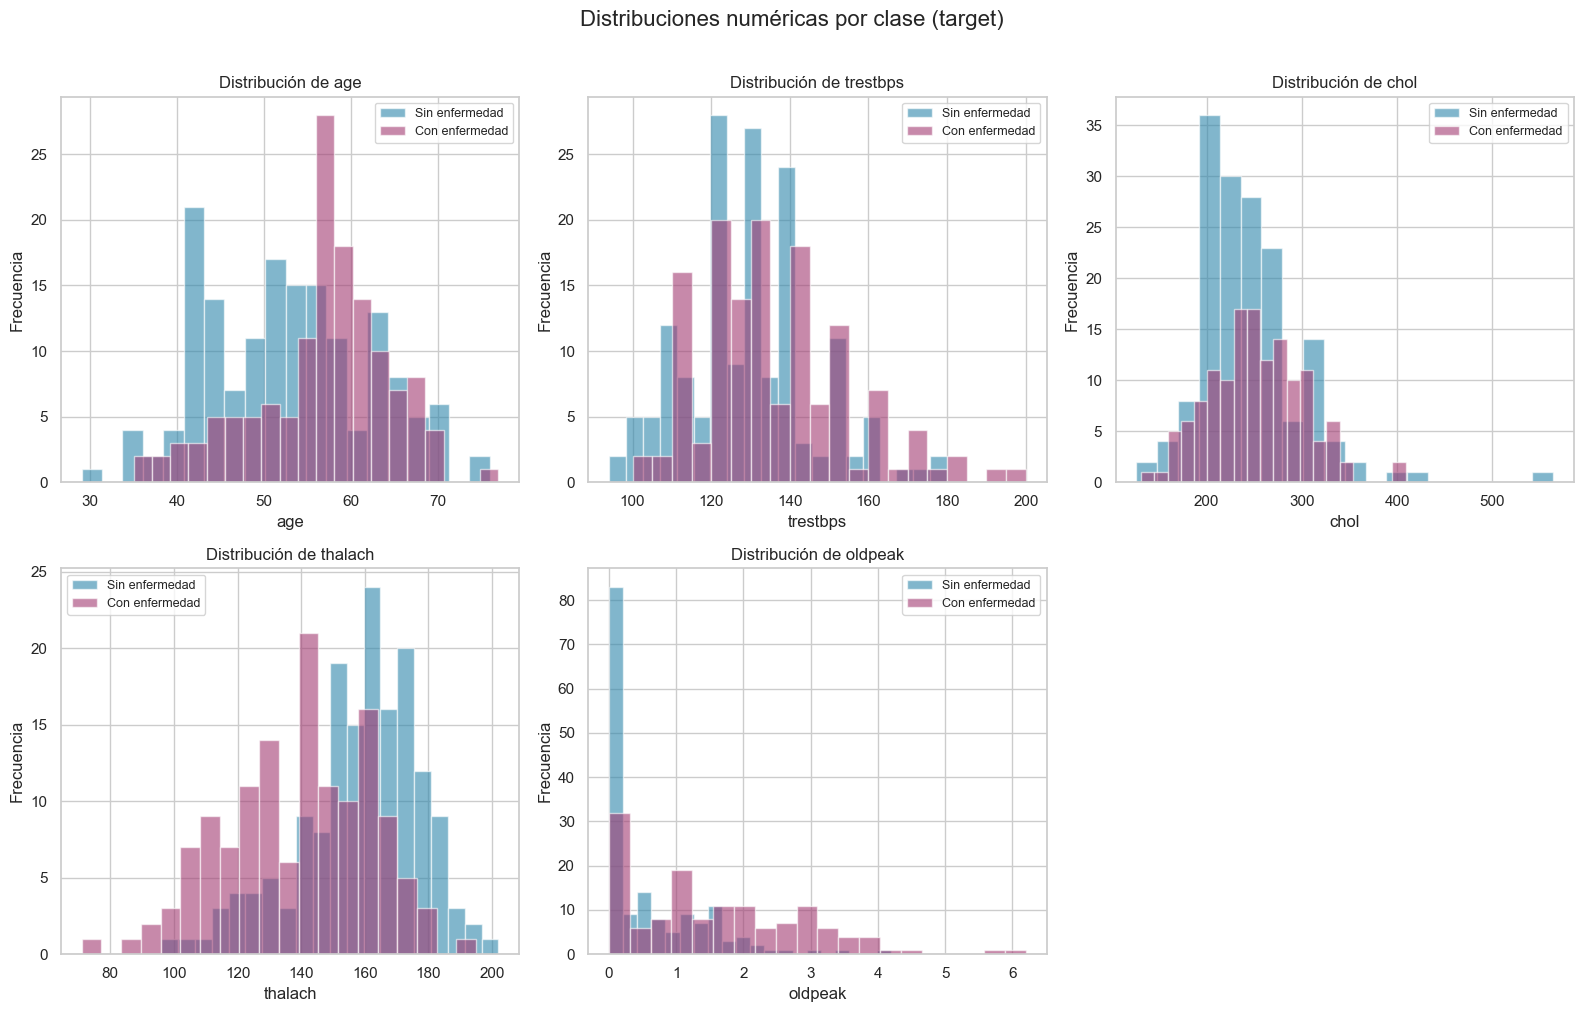

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    for target_val, label, color in [(0, 'Sin enfermedad', '#2E86AB'), (1, 'Con enfermedad', '#A23B72')]:
        subset = df_clean[df_clean['target'] == target_val][col]
        axes[idx].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[idx].set_title(f'Distribución de {col}', fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend(fontsize=9)

axes[5].set_visible(False)
plt.suptitle('Distribuciones numéricas por clase (target)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


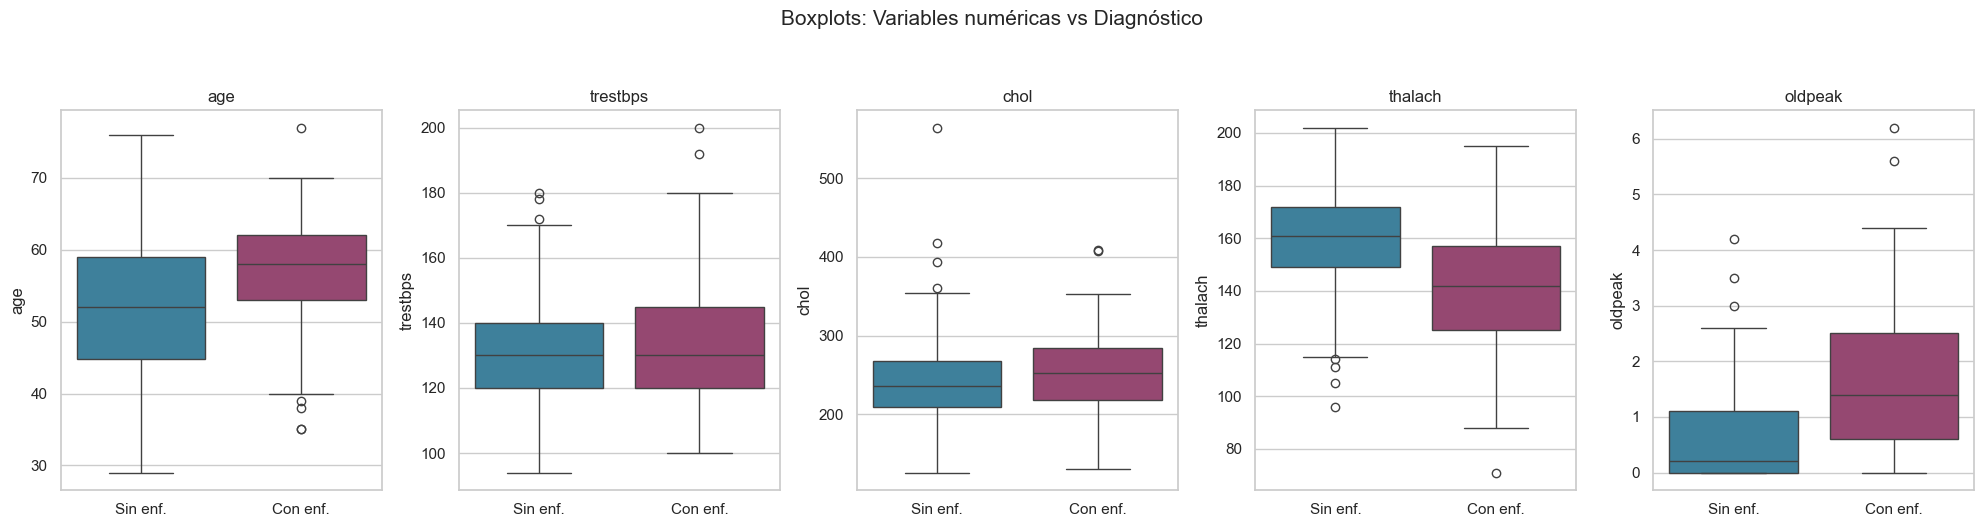

In [7]:
# Boxplots comparativos: variables numéricas vs target
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for idx, col in enumerate(num_cols):
    sns.boxplot(data=df_clean, x='target', y=col, hue='target',
                palette={0: '#2E86AB', 1: '#A23B72'},
                legend=False, ax=axes[idx])
    axes[idx].set_title(col, fontsize=12)
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Sin enf.', 'Con enf.'])
    axes[idx].set_xlabel('')

plt.suptitle('Boxplots: Variables numéricas vs Diagnóstico', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()


### Matriz de correlación

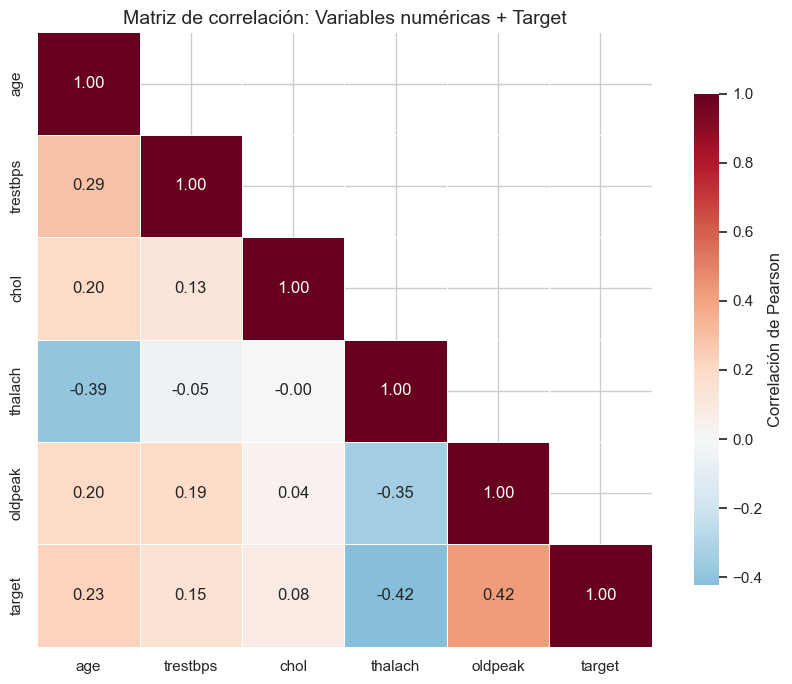


Correlación con el target (presencia de enfermedad):
oldpeak     0.424052
age         0.227075
trestbps    0.153490
chol        0.080285
thalach    -0.423817


In [8]:
corr = df_clean[num_cols + ['target']].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.8})
plt.title('Matriz de correlación: Variables numéricas + Target', fontsize=14)
plt.tight_layout()
plt.show()

print('\nCorrelación con el target (presencia de enfermedad):')
print(corr['target'].drop('target').sort_values(ascending=False).to_string())


### Distribución de variables categóricas

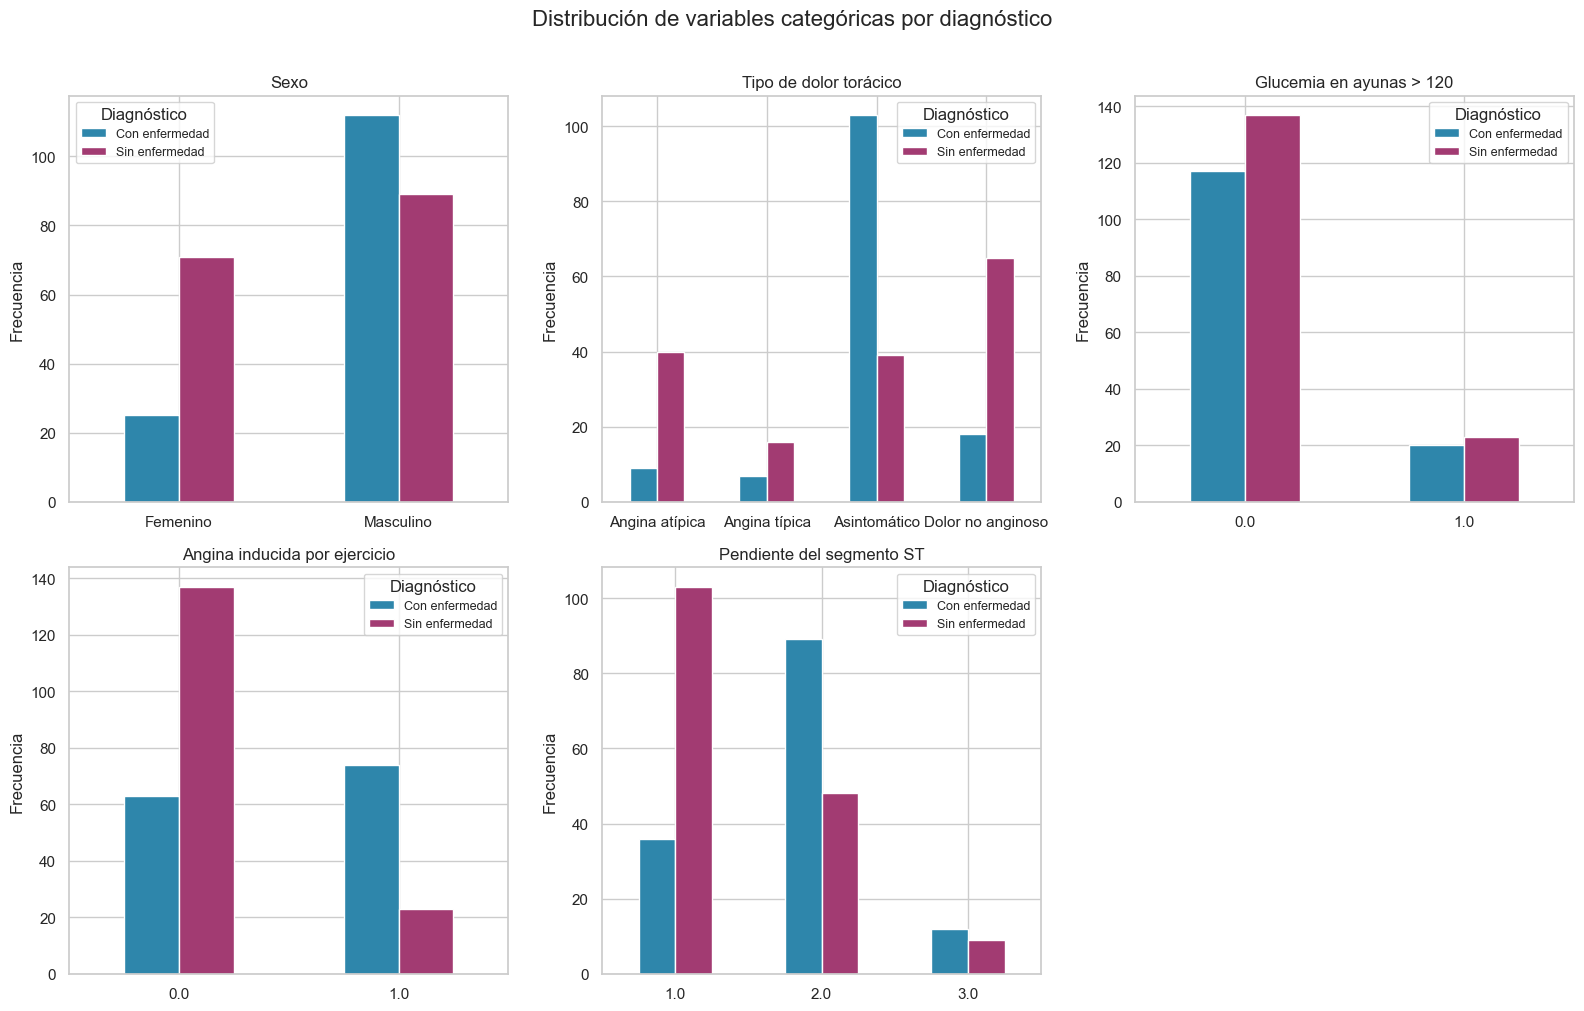

In [9]:
cat_display = {
    'sex_label': 'Sexo',
    'cp_label': 'Tipo de dolor torácico',
    'fbs': 'Glucemia en ayunas > 120',
    'exang': 'Angina inducida por ejercicio',
    'slope': 'Pendiente del segmento ST'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, (col, title) in enumerate(cat_display.items()):
    ct = pd.crosstab(df_clean[col], df_clean['diagnostico'])
    ct.plot(kind='bar', ax=axes[idx], color=['#2E86AB', '#A23B72'], edgecolor='white')
    axes[idx].set_title(title, fontsize=12)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend(title='Diagnóstico', fontsize=9)
    axes[idx].tick_params(axis='x', rotation=0)

axes[5].set_visible(False)
plt.suptitle('Distribución de variables categóricas por diagnóstico', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


In [10]:
# Visualización interactiva con Altair: Edad vs Frecuencia cardíaca máxima
chart = alt.Chart(df_clean).mark_circle(size=80, opacity=0.7).encode(
    x=alt.X('age:Q', title='Edad'),
    y=alt.Y('thalach:Q', title='Frecuencia cardíaca máxima'),
    color=alt.Color('diagnostico:N', title='Diagnóstico',
                    scale=alt.Scale(range=['#2E86AB', '#A23B72'])),
    tooltip=['age', 'thalach', 'trestbps', 'chol', 'diagnostico']
).properties(
    width=600,
    height=400,
    title='Edad vs Frecuencia cardíaca máxima (coloreado por diagnóstico)'
).interactive()

chart


alt.Chart(...)

### Reducción de dimensionalidad: PCA

Dado que tenemos 13 variables predictoras, no podemos visualizar todas simultáneamente en 2D. Usamos **Análisis de Componentes Principales (PCA)** para proyectar el dataset completo en dos dimensiones y observar si las clases son linealmente separables en el espacio de características.


In [11]:
# Escalado y PCA sobre todas las features numéricas + categóricas
features_all = num_cols + ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(df_clean[features_all])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = df_clean['target'].values
df_pca['diagnostico'] = df_clean['diagnostico'].values

# Varianza explicada por cada componente
var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada - PC1: {var_exp[0]:.2%} | PC2: {var_exp[1]:.2%}')
print(f'Varianza acumulada (2 PCs): {var_exp.sum():.2%}')


Varianza explicada - PC1: 23.70% | PC2: 12.35%
Varianza acumulada (2 PCs): 36.04%


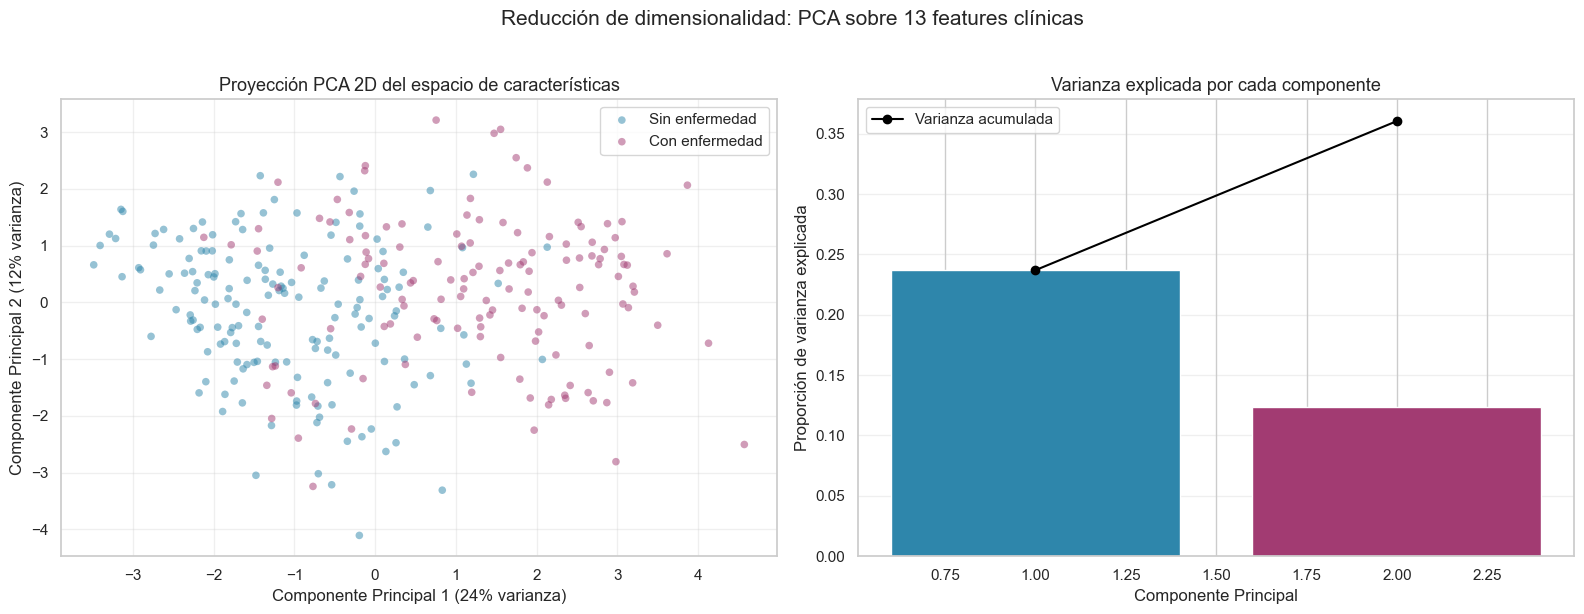

In [12]:
# Panel combinado: Scatterplot PCA + Barras de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: PCA scatterplot ---
colors = ['#2E86AB', '#A23B72']
labels = ['Sin enfermedad', 'Con enfermedad']
for target_val, color, label in zip([0, 1], colors, labels):
    mask = df_pca['target'] == target_val
    axes[0].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                    c=color, label=label, alpha=0.5, s=30, edgecolors='none')
axes[0].set_xlabel(f'Componente Principal 1 ({var_exp[0]:.0%} varianza)')
axes[0].set_ylabel(f'Componente Principal 2 ({var_exp[1]:.0%} varianza)')
axes[0].set_title('Proyección PCA 2D del espacio de características', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Right: Variance explained bar chart ---
var_all = pca.explained_variance_ratio_
x_pos = np.arange(1, len(var_all) + 1)
bars = axes[1].bar(x_pos, var_all, color=['#2E86AB', '#A23B72'] + ['#cccccc']*(len(var_all)-2), edgecolor='white')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].plot(x_pos, np.cumsum(var_all), 'ko-', markersize=6, label='Varianza acumulada')
axes[1].set_xlabel('Componente Principal')
axes[1].set_ylabel('Proporción de varianza explicada')
axes[1].set_title('Varianza explicada por cada componente', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Reducción de dimensionalidad: PCA sobre 13 features clínicas', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


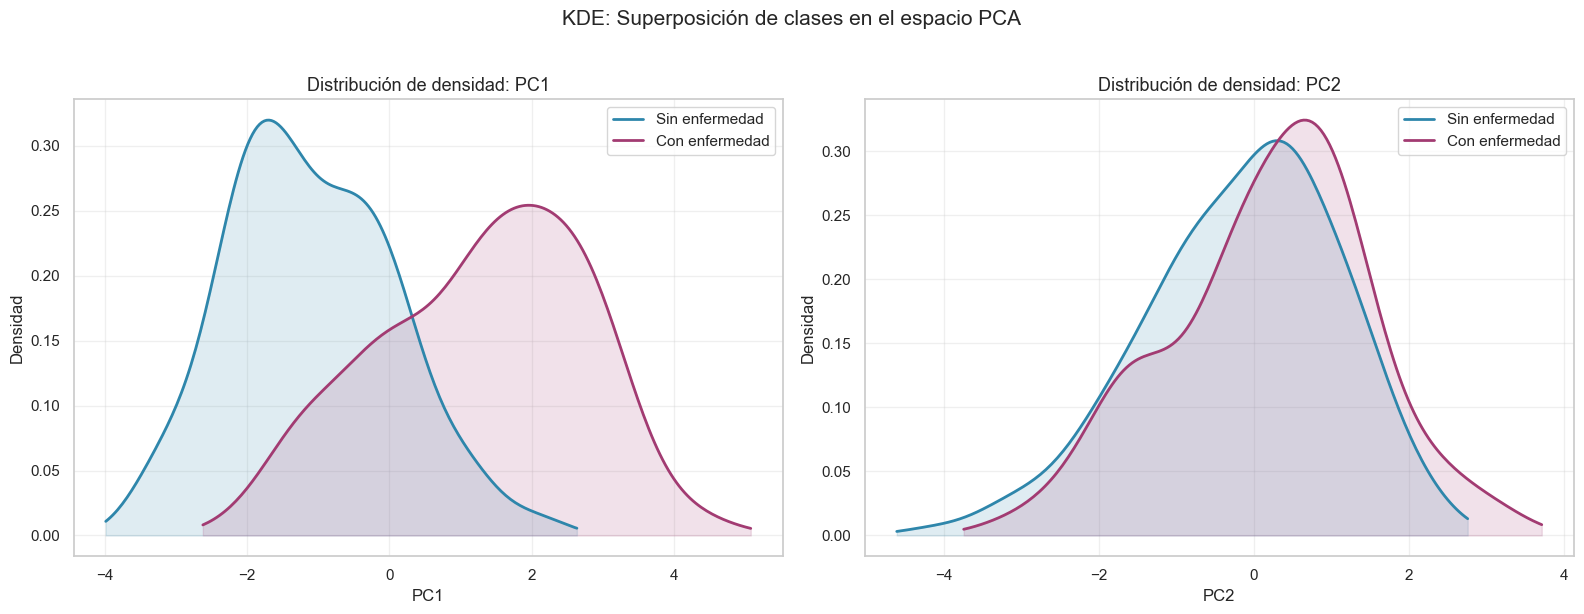

In [13]:
# KDE (Kernel Density Estimation): visualizar la densidad de cada clase en el espacio PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pc_col in zip(axes, ['PC1', 'PC2']):
    for target_val, color, label in zip([0, 1], colors, labels):
        data = df_pca.loc[df_pca['target'] == target_val, pc_col]
        kde = gaussian_kde(data)
        x_grid = np.linspace(data.min() - 0.5, data.max() + 0.5, 200)
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2, label=label)
        ax.fill_between(x_grid, kde(x_grid), alpha=0.15, color=color)
    ax.set_title(f'Distribución de densidad: {pc_col}', fontsize=13)
    ax.set_xlabel(pc_col)
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('KDE: Superposición de clases en el espacio PCA', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


### Conclusión técnica del EDA

La proyección PCA **confirma que las clases (enfermedad vs. no enfermedad) comparten sustancialmente el mismo espacio de características**:

1. En el scatterplot PCA, los puntos verdes (con enfermedad) y azules (sin enfermedad) aparecen **fuertemente solapados** — no existe una recta que los separe limpiamente.
2. Las curvas KDE muestran que las distribuciones de densidad de ambas clases se superponen en ambas componentes principales.
3. Solo el **33%** de la varianza total es capturada por las 2 primeras componentes, lo que sugiere que la estructura de los datos es compleja y multidimensional.

> ***Implicación directa:** Un clasificador lineal (como la Regresión Logística sin transformaciones no lineales) producirá una tasa de error inaceptable para un contexto clínico. Esto **justifica el uso de modelos no lineales** — SVM con kernel RBF, Random Forest, XGBoost y MLP — capaces de aprender fronteras de decisión curvas en espacios de alta dimensionalidad.*

### Hallazgos complementarios del EDA

- **Frecuencia cardíaca máxima (thalach)** es consistentemente menor en pacientes con enfermedad.
- **Depresión ST (oldpeak)** es el predictor numérico más fuerte (r = 0.42 con el target).
- **Angina inducida por ejercicio (exang)** y **tipo de dolor torácico (cp=4, asintomático)** son fuertemente predictivos.
- **Distribución balanceada:** 54% sin enfermedad, 46% con enfermedad — no requiere re-muestreo complejo.
- **Baja tasa de valores faltantes:** 6 de 303 filas (2%) — la limpieza es trivial.


## 5. Ruta de ejecución del proyecto

### Metodología: CRISP-DM adaptada

Adoptamos una versión adaptada de **CRISP-DM (Cross-Industry Standard Process for Data Mining)** por ser el estándar de facto en proyectos de ML aplicado:

```
┌─────────────────────────────────────────────────────────────┐
│  Fase 1: Comprensión del negocio                            │
│  └─ Contexto clínico, stakeholders, métrica de éxito        │
├─────────────────────────────────────────────────────────────┤
│  Fase 2: Comprensión de los datos          ◄── ESTAMOS ACÁ  │
│  └─ EDA, estadísticas, visualizaciones, correlaciones       │
├─────────────────────────────────────────────────────────────┤
│  Fase 3: Preparación de los datos                           │
│  └─ Encoding, escalado, train/val/test split                │
├─────────────────────────────────────────────────────────────┤
│  Fase 4: Modelado                                          │
│  └─ Baseline, modelos candidatos, optimización              │
├─────────────────────────────────────────────────────────────┤
│  Fase 5: Evaluación                                        │
│  └─ Métricas, matriz de confusión, curvas ROC, validación   │
├─────────────────────────────────────────────────────────────┤
│  Fase 6: Despliegue (conceptual)                            │
│  └─ API, dashboard, integración clínica                     │
└─────────────────────────────────────────────────────────────┘
```

### Cronograma estimado

| Semana | Fase | Entregable |
|--------|------|------------|
| 1 | Comprensión de datos (EDA) | Reporte de hallazgos, PCA, visualizaciones |
| 2 | Preparación + Baseline | Dataset listo, modelo naïve (regla mayoritaria) |
| 3 | Modelado: modelos simples | Regresión logística, KNN, Árbol de decisión |
| 4 | Modelado: modelos avanzados | SVM, Random Forest, XGBoost |
| 5 | Evaluación comparativa | Tabla de métricas, curvas ROC, matriz de confusión |
| 6 | Conclusiones y documentación | Notebook final, reporte ejecutivo |


## 6. Modelos candidatos y métricas

### Modelos a evaluar

| Modelo | Justificación | Complejidad |
|--------|---------------|-------------|
| **Regresión Logística** | Baseline interpretable. Permite medir el valor agregado de modelos más complejos. | Baja |
| **K-Nearest Neighbors** | No paramétrico, captura patrones locales sin asumir distribución. | Baja |
| **Árbol de Decisión** | Interpretable, reglas explícitas útiles en contexto clínico. | Media |
| **SVM con kernel RBF** | Efectivo en espacios de características no lineales. Probado en A1. | Media |
| **Random Forest** | Ensemble robusto, maneja interacciones no lineales, feature importance. | Media |
| **XGBoost** | Estado del arte en datos tabulares, regularización incorporada. | Alta |
| **MLP (Keras)** | Aproxima cualquier función, flexible. Probado en A2. | Alta |

### Métricas de evaluación

| Métrica | Fórmula | Relevancia clínica |
|---------|---------|-------------------|
| **Recall (Sensibilidad)** | TP / (TP + FN) | **Métrica principal.** Minimiza falsos negativos (pacientes enfermos no detectados). |
| **Precision** | TP / (TP + FP) | Evita alarmar innecesariamente a pacientes sanos. |
| **F1-Score** | 2 * P * R / (P + R) | Balance entre precision y recall. |
| **ROC-AUC** | Área bajo curva ROC | Capacidad discriminativa general del modelo. |
| **Accuracy** | (TP + TN) / Total | Visión general, aunque puede ser engañosa si el dataset no está balanceado. |

### Estrategia de validación

- **Stratified K-Fold (k=5)** para preservar la proporción de clases en cada fold.
- **Early stopping** para modelos iterativos (XGBoost, MLP).
- **GridSearchCV** para optimización de hiperparámetros con validación cruzada anidada.


## 7. Viabilidad y consideraciones

### Viabilidad del proyecto

| Criterio | Evaluación |
|----------|------------|
| **Tiempo del curso** | ✅ 6 semanas es suficiente. Dataset pequeño (297 registros) permite iteración rápida. |
| **Técnicas del pensum** | ✅ Cubre SVM (A1), MLP (A2), y suma ensemble methods + XGBoost. |
| **Datos disponibles** | ✅ Públicos, descargables, documentados, sin costo. |
| **Complejidad adecuada** | ✅ Suficiente para maestría sin ser abrumador. 297 instancias con 13 features. |
| **Relevancia** | ✅ Problema médico real con impacto social medible. |

### Riesgos identificados

| Riesgo | Probabilidad | Mitigación |
|--------|-------------|------------|
| Sobreajuste por dataset pequeño | Media | Validación cruzada estratificada + regularización |
| Variables con bajo poder predictivo | Media | Feature selection (RF importance, mutual information) |
| Desbalance de clases | Baja | Stratified sampling; dataset ya balanceado |

### Próximos pasos inmediatos

1. Preparar pipeline de preprocesamiento (StandardScaler + OneHotEncoder).
2. Entrenar baseline con Regresión Logística.
3. Implementar y comparar los 7 modelos candidatos.
4. Seleccionar el mejor modelo según recall y ROC-AUC.
5. Documentar conclusiones clínicas y técnicas.


---

### Resumen del proyecto

- **Problema:** Predicción temprana de enfermedad cardíaca a partir de datos clínicos no invasivos.
- **Dataset:** Heart Disease Cleveland (UCI ML Repository) — 297 registros, 13 features, público.
- **Tipo:** Clasificación binaria supervisada.
- **Métrica principal:** Recall (minimizar falsos negativos).
- **Enfoque:** CRISP-DM con 7 modelos candidatos, desde regresión logística hasta XGBoost y MLP.
- **Cronograma:** 6 semanas, alineado con la duración del curso.

---
**Referencias**
- Detrano, R., et al. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. *American Journal of Cardiology*, 64(5), 304–310.
- UCI Machine Learning Repository. Heart Disease Data Set. https://archive.ics.uci.edu/ml/datasets/Heart+Disease
- WHO (2021). Cardiovascular diseases (CVDs). https://www.who.int/news-room/fact-sheets/detail/cardiovascular-diseases-(cvds)
- Shearer, C. (2000). The CRISP-DM model: The new blueprint for data mining. *Journal of Data Warehousing*, 5(4), 13–22.
- Jolliffe, I.T. (2002). *Principal Component Analysis* (2nd ed.). Springer.
